# Connect Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is CUDA available? False


# Install **pytorch-tabnet, optuna**

In [3]:
!pip install pytorch-tabnet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.6 MB/s eta 0:00:00


# Important Libraries

In [4]:
import torch
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pytorch_tabnet.metrics import Metric
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import joblib
import os
import gc

# Sentinel-2

## Data Loading


In [ ]:
s2_file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_with_veg_data.csv"

print("Loading data...")
s2df = pd.read_csv(s2_file_path)
print("Data is loaded")

print("\nData preparation...")

s2df1 = s2df.loc[s2df["age"] != 5].dropna()

s2df1.drop(columns=["age", "height", "basal_area", "poly_id", "S2_Date"], axis=1, inplace=True)

s2_y = s2df1["stock_per_ha"]
S2_X = s2df1.drop(columns=["stock_per_ha"], axis=1)

S2_train, S2_val, s2_train, s2_val = train_test_split(S2_X, s2_y, test_size=0.15, random_state=42, stratify=s2_y)
S2_train, S2_test, s2_train, s2_test = train_test_split(S2_train, s2_train, test_size=0.15, random_state=42, stratify=s2_train)

print(f"\nDatasets are read! S2_train shape: {S2_train.shape}, S2_test shape: {S2_test.shape}, S2_val shape: {S2_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! S2_train shape: (284286, 52), S2_test shape: (50169, 52), S2_val shape: (59022, 52)


## Training with optimized Hyper-parameters


### XGBoost Model Training, Evaluation and Plot


Starting XGBoost training...
[0]	validation_0-rmse:80.11280
[1]	validation_0-rmse:79.86156
[2]	validation_0-rmse:79.61406
[3]	validation_0-rmse:79.36981
[4]	validation_0-rmse:79.13011
[5]	validation_0-rmse:78.89883
[6]	validation_0-rmse:78.67034
[7]	validation_0-rmse:78.44826
[8]	validation_0-rmse:78.21966
[9]	validation_0-rmse:77.99439
[10]	validation_0-rmse:77.77695
[11]	validation_0-rmse:77.55878
[12]	validation_0-rmse:77.35031
[13]	validation_0-rmse:77.13700
[14]	validation_0-rmse:76.93326
[15]	validation_0-rmse:76.72938
[16]	validation_0-rmse:76.52702
[17]	validation_0-rmse:76.32673
[18]	validation_0-rmse:76.13641
[19]	validation_0-rmse:75.94163
[20]	validation_0-rmse:75.75015
[21]	validation_0-rmse:75.56226
[22]	validation_0-rmse:75.37411
[23]	validation_0-rmse:75.19482
[24]	validation_0-rmse:75.01407
[25]	validation_0-rmse:74.83686
[26]	validation_0-rmse:74.66367
[27]	validation_0-rmse:74.50353
[28]	validation_0-rmse:74.34261
[29]	validation_0-rmse:74.17794
[30]	validation_0-rm

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:46:02] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Final Model RMSE: 61.422
Final Model MAE: 46.762


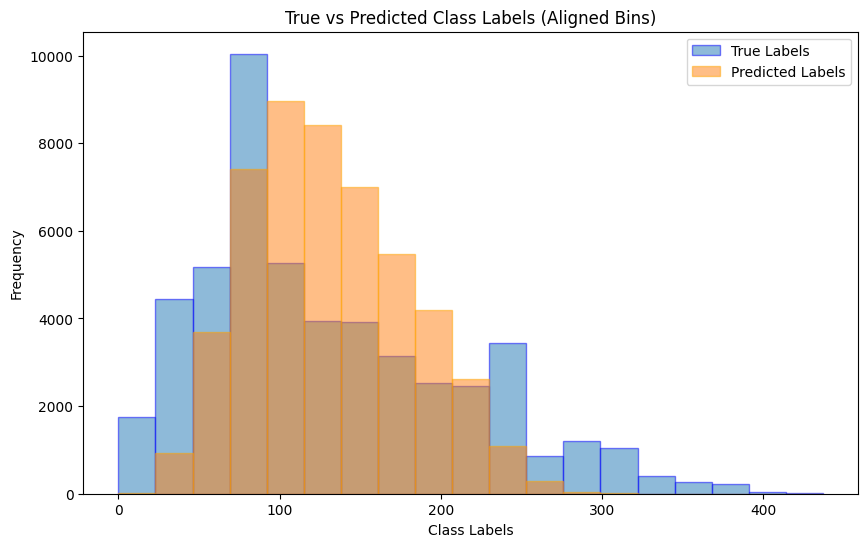

In [ ]:
print("\nStarting XGBoost training...")
# Best Regressor Params:
# {'subsample': 0.7,
# 'n_estimators': 2000,
# 'min_child_weight': 7,
# 'max_depth': 15,
# 'learning_rate': 0.01,
# 'gamma': 0.5,
# 'colsample_bytree': 0.7}

XGBmodel_stock = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    n_estimators=2000,
    max_depth = 15,
    learning_rate = 0.01,
    colsample_bytree = 0.7,
    subsample = 0.7,
    min_child_weight = 7,
    gamma = 0.5,
    device="cuda",
    early_stopping_rounds=50
)

XGBmodel_stock.fit(
    S2_train, s2_train,
    eval_set=[(S2_val, s2_val)]
)
print("XGBoost Training finished")

# Evaluate
print("\nEvaluating Final Hurdle Model on Test Set...")
y_pred_final = XGBmodel_stock.predict(S2_test)

rmse_final = np.sqrt(mean_squared_error(s2_test, y_pred_final))
mae_final = mean_absolute_error(s2_test, y_pred_final)

print(f"Final Model RMSE: {rmse_final:.3f}")
print(f"Final Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))
shared_bins = np.arange(0, 460, 23)

plt.hist(s2_test, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

### Tabnet Model Training, Evaluation and Plot

In [ ]:
S2_train_np = S2_train.values.astype(np.float32) if isinstance(S2_train, pd.DataFrame) else S2_train.astype(np.float32)
s2_train_np = s2_train.values.astype(np.float32).reshape(-1, 1) if isinstance(s2_train, pd.Series) else s2_train.astype(np.float32).reshape(-1, 1)

S2_val_np = S2_val.values.astype(np.float32) if isinstance(S2_val, pd.DataFrame) else S2_val.astype(np.float32)
s2_val_np = s2_val.values.astype(np.float32).reshape(-1, 1) if isinstance(s2_val, pd.Series) else s2_val.astype(np.float32).reshape(-1, 1)

S2_test_np = S2_test.values.astype(np.float32) if isinstance(S2_test, pd.DataFrame) else S2_test.astype(np.float32)
s2_test_np = s2_test.values.astype(np.float32).reshape(-1, 1) if isinstance(s2_test, pd.Series) else s2_test.astype(np.float32).reshape(-1, 1)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 13993.58057| valid_rmse: 79.91636|  0:00:07s
epoch 1  | loss: 5148.80773| valid_rmse: 78.17246|  0:00:14s
epoch 2  | loss: 4833.9766| valid_rmse: 76.85864|  0:00:21s
epoch 3  | loss: 4691.12125| valid_rmse: 74.72905|  0:00:27s
epoch 4  | loss: 4594.15817| valid_rmse: 75.95512|  0:00:34s
epoch 5  | loss: 4540.61938| valid_rmse: 73.81532|  0:00:41s
epoch 6  | loss: 4434.52268| valid_rmse: 71.79616|  0:00:48s
epoch 7  | loss: 4361.48864| valid_rmse: 70.86074|  0:00:55s
epoch 8  | loss: 4313.1513| valid_rmse: 69.15131|  0:01:01s
epoch 9  | loss: 4294.40368| valid_rmse: 65.25603|  0:01:08s
epoch 10 | loss: 4229.38854| valid_rmse: 66.23556|  0:01:14s
epoch 11 | loss: 4199.39663| valid_rmse: 65.22687|  0:01:21s
epoch 12 | loss: 4169.51384| valid_rmse: 64.13561|  0:01:28s
epoch 13 | loss: 4146.58659| valid_rmse: 64.4301 |  0:01:35s
epoch 14 | loss: 4132.6303| valid_rmse: 64.64648|  0:01:42s
epoch 15 | loss: 4110.92938| valid_rmse: 64.72618|  0:01:49s
epoch 16 | loss: 4084.5111

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Evaluating Final Model on Test Set...
Final Tabnet Model RMSE: 59.620
Final Tabnet Model MAE: 44.563


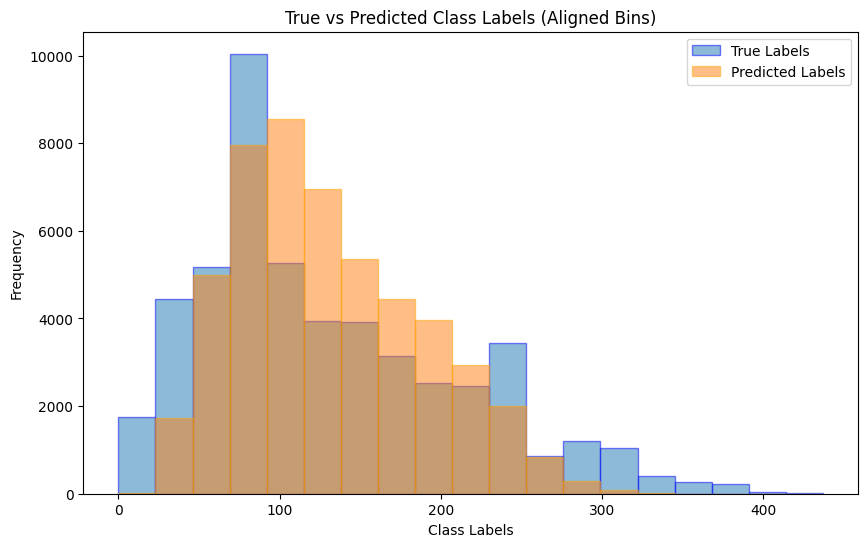

In [ ]:
# Best Parameters Found:
#   n_d: 64
#   n_steps: 5
#   gamma: 1.7994446317157529
#   lambda_sparse: 0.000516096733201913
#   lr: 0.00762200595484607


Tabnet_stock = TabNetRegressor(
    n_d= 64,
    n_a= 64,
    n_steps= 5,
    gamma= 1.7994446317157529,
    lambda_sparse= 0.000516096733201913,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.00762200595484607),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

Tabnet_stock.fit(
    X_train=S2_train_np, y_train=s2_train_np,
    eval_set=[(S2_val_np, s2_val_np)],
    eval_name=['valid'],
    eval_metric=['rmse'],
    max_epochs=150,
    patience=20,
    batch_size=4096,
    virtual_batch_size=512
)

# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = Tabnet_stock.predict(S2_test_np)

rmse_final = np.sqrt(mean_squared_error(s2_test_np, y_pred_final))
mae_final = mean_absolute_error(s2_test_np, y_pred_final)

print(f"Final Tabnet Model RMSE: {rmse_final:.3f}")
print(f"Final Tabnet Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))

# Force bins to be exactly 0, 1, 2, ..., 24
shared_bins = np.arange(0, 460, 23)

plt.hist(s2_test_np, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

# Alpha Earth Foundation + Sentinel-2

## Data Loading

In [5]:
aef_file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_aef_with_veg_data.csv"

print("Loading data...")
aefdf = pd.read_csv(aef_file_path)
print("Data is loaded")

print("\nData preparation...")

aefdf1 = aefdf.loc[aefdf["age"] != 5].dropna()

aefdf1.drop(columns=["age", "height", "basal_area", "poly_id", "S2_Date"], axis=1, inplace=True)

aef_y = aefdf1["stock_per_ha"]
AEF_X = aefdf1.drop(columns=["stock_per_ha"], axis=1)

AEF_train, AEF_val, aef_train, aef_val = train_test_split(AEF_X, aef_y, test_size=0.15, random_state=42, stratify=aef_y)
AEF_train, AEF_test, aef_train, aef_test = train_test_split(AEF_train, aef_train, test_size=0.15, random_state=42, stratify=aef_train)

print(f"\nDatasets are read! AEF_train shape: {AEF_train.shape}, AEF_test shape: {AEF_test.shape}, AEF_val shape: {AEF_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! AEF_train shape: (284117, 308), AEF_test shape: (50139, 308), AEF_val shape: (58987, 308)


##Training with optimized Hyper-parameters

### XGBoost Model Training, Evaluation and Plot


Starting XGBoost training...


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [05:45:18] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [05:45:18] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-rmse:76.91891
[1]	validation_0-rmse:73.90885
[2]	validation_0-rmse:71.32528
[3]	validation_0-rmse:69.10728
[4]	validation_0-rmse:67.15715
[5]	validation_0-rmse:65.50035
[6]	validation_0-rmse:64.09621
[7]	validation_0-rmse:62.87446
[8]	validation_0-rmse:61.81223
[9]	validation_0-rmse:60.92110
[10]	validation_0-rmse:60.10787
[11]	validation_0-rmse:59.38354
[12]	validation_0-rmse:58.77009
[13]	validation_0-rmse:58.21740
[14]	validation_0-rmse:57.74074
[15]	validation_0-rmse:57.30913
[16]	validation_0-rmse:56.94071
[17]	validation_0-rmse:56.59699
[18]	validation_0-rmse:56.28866
[19]	validation_0-rmse:55.98663
[20]	validation_0-rmse:55.70831
[21]	validation_0-rmse:55.47471
[22]	validation_0-rmse:55.24232
[23]	validation_0-rmse:55.03003
[24]	validation_0-rmse:54.82473
[25]	validation_0-rmse:54.63427
[26]	validation_0-rmse:54.45466
[27]	validation_0-rmse:54.29064
[28]	validation_0-rmse:54.10063
[29]	validation_0-rmse:53.94128
[30]	validation_0-rmse:53.80272
[31]	validation_0-

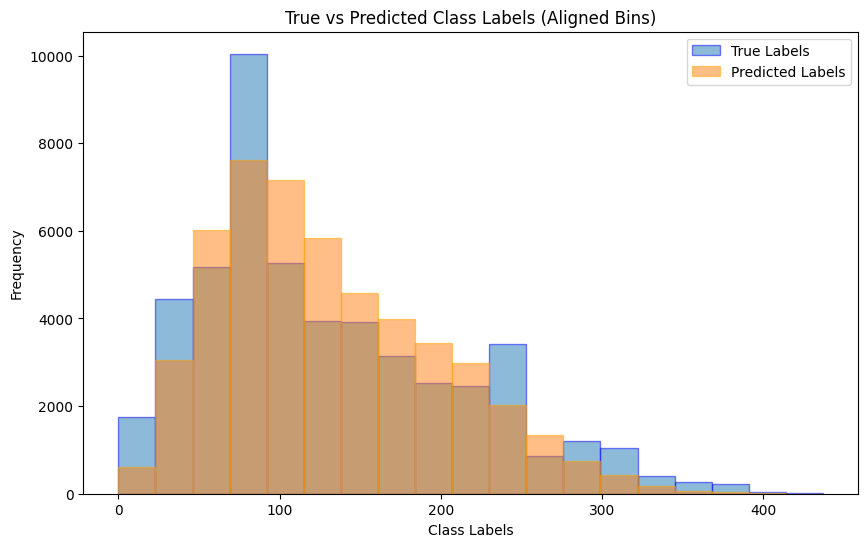

In [6]:
print("\nStarting XGBoost training...")
# Best Regressor Params:
# {'subsample': 0.9,
# 'n_estimators': 2000,
# 'min_child_weight': 7,
# 'max_depth': 9,
# 'learning_rate': 0.1,
# 'gamma': 0.1,
# 'colsample_bytree': 0.9}

XGBmodel_stock = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    n_estimators=2000,
    max_depth = 9,
    learning_rate = 0.1,
    colsample_bytree = 0.9,
    subsample = 0.9,
    min_child_weight = 7,
    gamma = 0.1,
    device="cuda",
    early_stopping_rounds=50
)

XGBmodel_stock.fit(
    AEF_train, aef_train,
    eval_set=[(AEF_val, aef_val)]
)
print("XGBoost Training finished")

# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = XGBmodel_stock.predict(AEF_test)

rmse_final = np.sqrt(mean_squared_error(aef_test, y_pred_final))
mae_final = mean_absolute_error(aef_test, y_pred_final)

print(f"Final Model RMSE: {rmse_final:.3f}")
print(f"Final Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))
shared_bins = np.arange(0, 460, 23)

plt.hist(aef_test, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

### Tabnet Model Training, Evaluation and Plot

In [ ]:
AEF_train_np = AEF_train.values.astype(np.float32) if isinstance(AEF_train, pd.DataFrame) else AEF_train.astype(np.float32)
aef_train_np = aef_train.values.astype(np.float32).reshape(-1, 1) if isinstance(aef_train, pd.Series) else aef_train.astype(np.float32).reshape(-1, 1)

AEF_val_np = AEF_val.values.astype(np.float32) if isinstance(AEF_val, pd.DataFrame) else AEF_val.astype(np.float32)
aef_val_np = aef_val.values.astype(np.float32).reshape(-1, 1) if isinstance(aef_val, pd.Series) else aef_val.astype(np.float32).reshape(-1, 1)

AEF_test_np = AEF_test.values.astype(np.float32) if isinstance(AEF_test, pd.DataFrame) else AEF_test.astype(np.float32)
aef_test_np = aef_test.values.astype(np.float32).reshape(-1, 1) if isinstance(aef_test, pd.Series) else aef_test.astype(np.float32).reshape(-1, 1)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 11646.85936| valid_rmse: 77.14592|  0:00:07s
epoch 1  | loss: 3393.79898| valid_rmse: 76.4918 |  0:00:15s
epoch 2  | loss: 3075.26746| valid_rmse: 74.93225|  0:00:21s
epoch 3  | loss: 2869.78132| valid_rmse: 71.83878|  0:00:28s
epoch 4  | loss: 2704.547| valid_rmse: 68.75539|  0:00:35s
epoch 5  | loss: 2534.16165| valid_rmse: 66.3315 |  0:00:42s
epoch 6  | loss: 2361.24964| valid_rmse: 60.58023|  0:00:49s
epoch 7  | loss: 2211.12549| valid_rmse: 56.24953|  0:00:56s
epoch 8  | loss: 2060.19048| valid_rmse: 52.61715|  0:01:03s
epoch 9  | loss: 1922.64431| valid_rmse: 49.90616|  0:01:11s
epoch 10 | loss: 1797.65681| valid_rmse: 47.40482|  0:01:17s
epoch 11 | loss: 1678.73423| valid_rmse: 45.68148|  0:01:24s
epoch 12 | loss: 1570.03932| valid_rmse: 43.84826|  0:01:31s
epoch 13 | loss: 1465.88856| valid_rmse: 41.94141|  0:01:38s
epoch 14 | loss: 1376.11158| valid_rmse: 40.52824|  0:01:45s
epoch 15 | loss: 1292.55968| valid_rmse: 39.82223|  0:01:53s
epoch 16 | loss: 1217.100

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Evaluating Final Model on Test Set...
Final Tabnet Model RMSE: 22.972
Final Tabnet Model MAE: 15.538


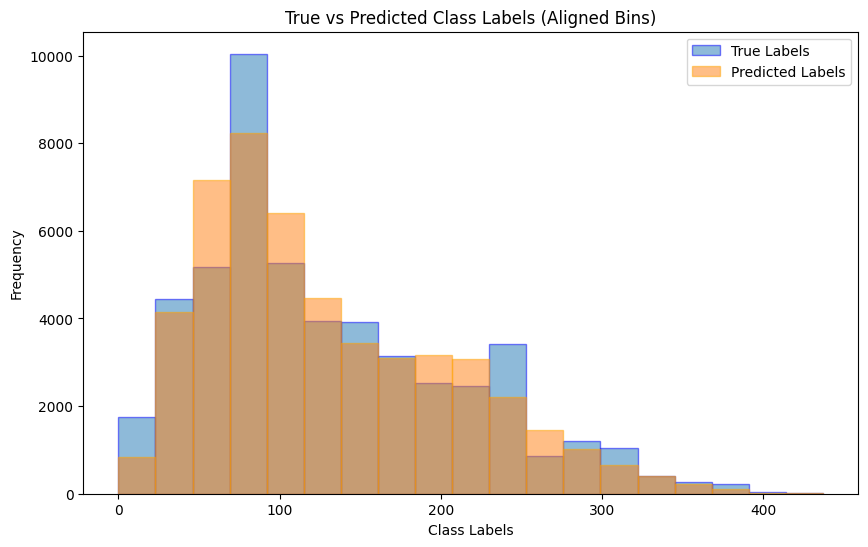

In [ ]:
# Best Parameters Found:
#   n_d: 64
#   n_steps: 4
#   gamma: 1.0094621060357858
#   lambda_sparse: 2.317311523727845e-05
#   lr: 0.008578113555072568


Tabnet_stock = TabNetRegressor(
    n_d= 64,
    n_a= 64,
    n_steps= 4,
    gamma= 1.0094621060357858,
    lambda_sparse= 2.317311523727845e-05,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.008578113555072568),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

Tabnet_stock.fit(
    X_train=AEF_train_np, y_train=aef_train_np,
    eval_set=[(AEF_val_np, aef_val_np)],
    eval_name=['valid'],
    eval_metric=['rmse'],
    max_epochs=150,
    patience=20,
    batch_size=4096,
    virtual_batch_size=512
)

# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = Tabnet_stock.predict(AEF_test_np)

rmse_final = np.sqrt(mean_squared_error(aef_test_np, y_pred_final))
mae_final = mean_absolute_error(aef_test_np, y_pred_final)

print(f"Final Tabnet Model RMSE: {rmse_final:.3f}")
print(f"Final Tabnet Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))

# Force bins to be exactly 0, 1, 2, ..., 24
shared_bins = np.arange(0, 460, 23)

plt.hist(aef_test_np, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

# Feature Importance Analyses on Alpha Earth Foundation + Sentinel-2 dataset

## XGBoost SHAP value

In [7]:
feature_names = AEF_train.columns.tolist()

print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(XGBmodel_stock)

print("Calculating SHAP values...")
shap_values = explainer.shap_values(AEF_test)

Initializing SHAP TreeExplainer...
Calculating SHAP values...


### Top 20 Features

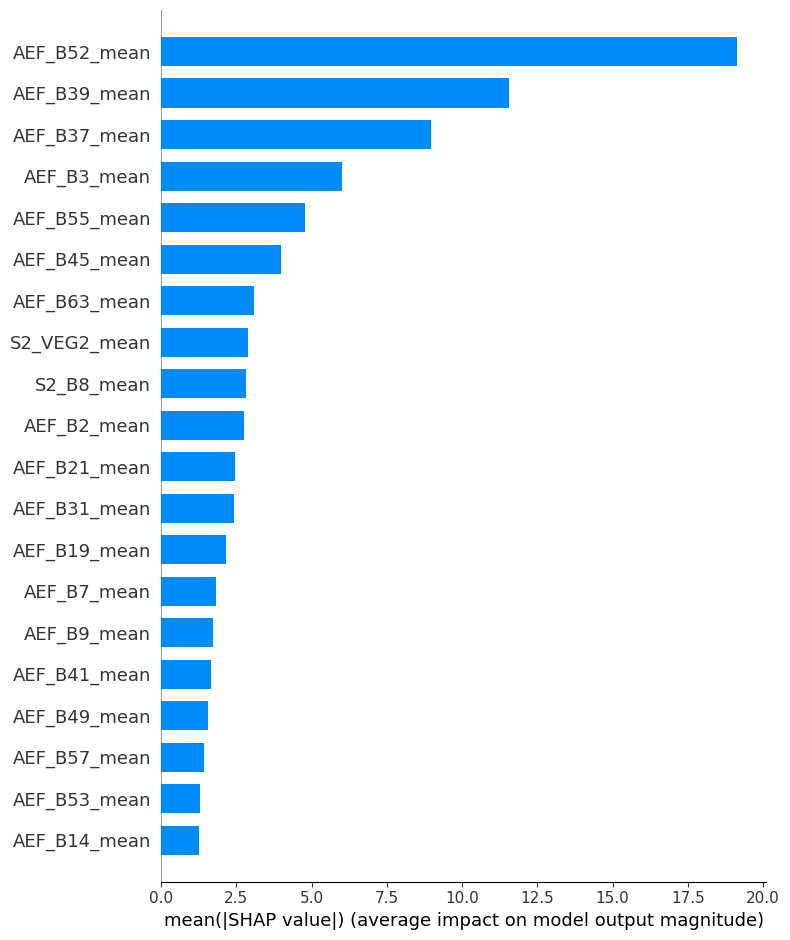

In [8]:
shap.summary_plot(shap_values, AEF_test, feature_names=feature_names, plot_type="bar")

### Top 100 Features

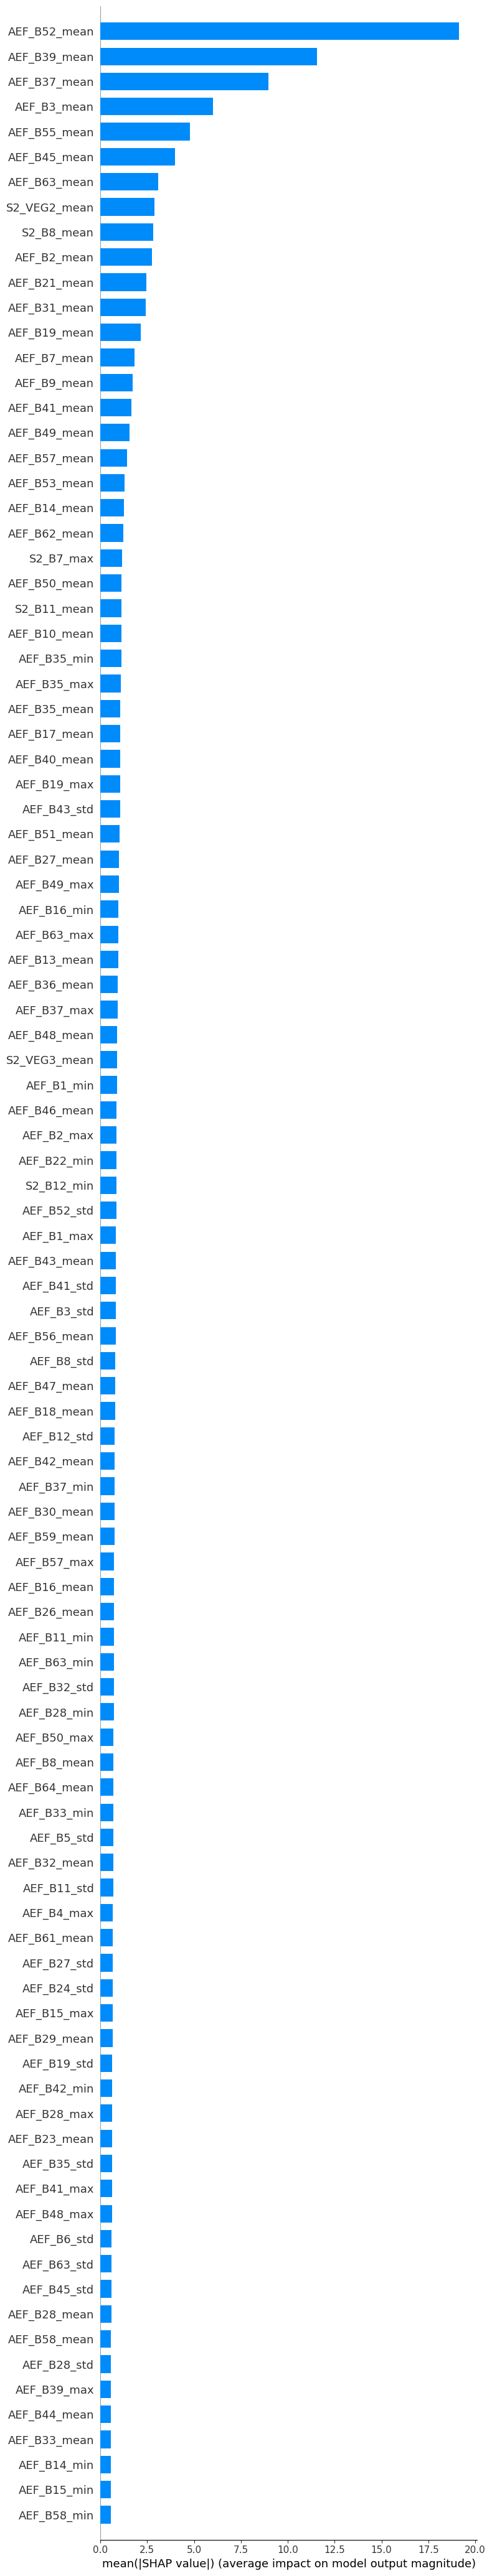

In [9]:
shap.summary_plot(shap_values, AEF_test, feature_names=feature_names, plot_type="bar", max_display=100)

## Tabnet SHAP value

In [ ]:
import shap

feature_names = AEF_train.columns.tolist()

# Create a small "Test" sample to explain
test_indices = np.random.choice(AEF_test_np.shape[0], 2000, replace=False)
X_test_sample = AEF_test_np[test_indices]

# Initialize the SHAP Explainer
print("Initializing SHAP Explainer...")
explainer = shap.KernelExplainer(
    lambda x: Tabnet_stock.predict(x).flatten(),
    shap.kmeans(AEF_train_np, 100)
)

# Calculate SHAP values for the test sample
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test_sample)

Initializing SHAP Explainer...
Calculating SHAP values...


  0%|          | 0/2000 [00:00<?, ?it/s]

### Top 20 Features

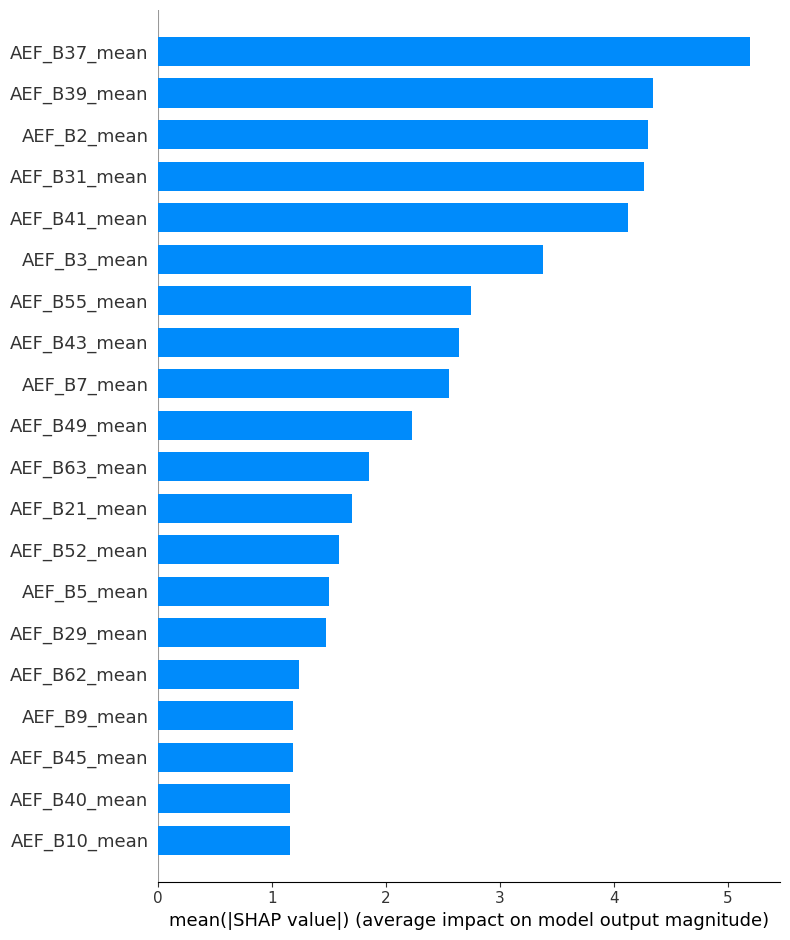

In [ ]:
shap.summary_plot(shap_values, AEF_test_np, feature_names=feature_names, plot_type="bar")

### Top 100 Features

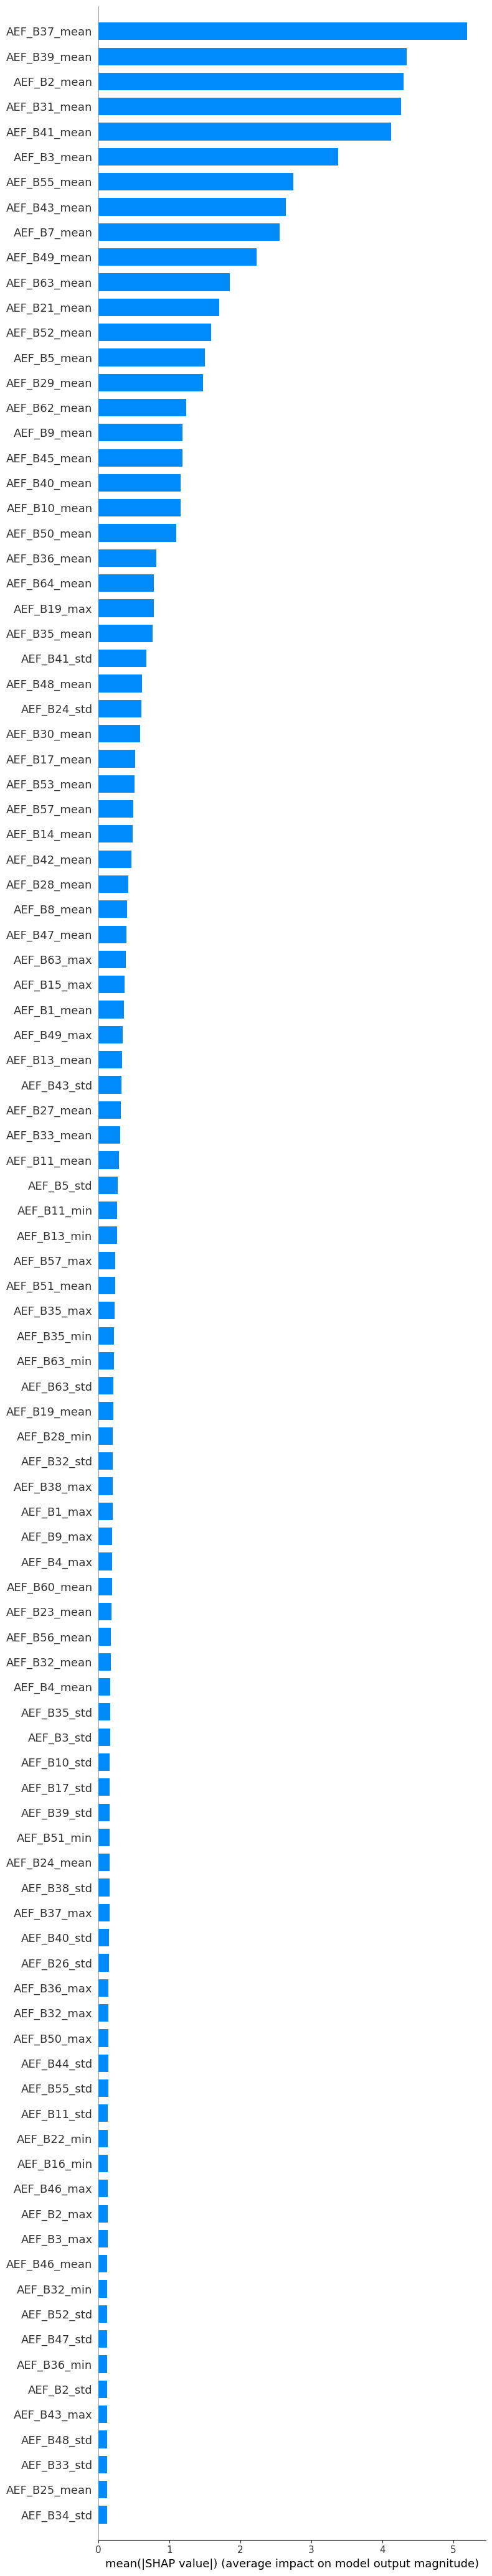

In [ ]:
shap.summary_plot(shap_values, AEF_test_np, feature_names=feature_names, plot_type="bar", max_display = 100)